# 🫀 PTB-XL Notebook 07 — Statistical Robustness (Bootstrap CIs · Fmax · macro-AUPRC)

## Module 0 — Why this notebook exists

Notebooks 01–06 report **single point estimates** on one held-out fold (fold 10, N = 2,198):
macro-AUC ≈ 0.923 (best single) / 0.924 (AUC-weighted ensemble), plus per-class AUC, ECE,
error-detection AUC and lead-ablation drops. None of those numbers currently carries an
**uncertainty interval**, and only macro-AUC is reported — no threshold-based summary.

Every benchmark-style paper this project compares against does more:

| Paper | What they add on top of a point estimate |
|---|---|
| **Strodthoff et al. 2020** | 1000× test-set **bootstrap** 95% CIs; reports **Fmax** (threshold swept to maximise F1) alongside macro-AUC. |
| **Gitau et al. 2025** (replication) | 3× repeated bootstrap; also 3-fold CV for the headline model. |
| **Jafari & Jafari 2026** | 5-fold cross-validation for model selection; reports **macro-AUPRC** (0.47) to expose rare-class difficulty that AUC hides. |

This notebook closes that gap for the current results. It adds three things and nothing else:

1. **Non-parametric bootstrap 95% confidence intervals** for every headline metric (paired across models).
2. **Fmax** — the best macro-F1 reachable by sweeping a single global threshold (Strodthoff's secondary metric).
3. **macro-AUPRC** (macro-averaged average precision) — a proper precision–recall summary that is far
   more sensitive than AUC to the rare classes (HYP, CD).

It also runs a **paired bootstrap test** of "does the AUC-weighted ensemble beat the best single model?"
— the project's own NB02/NB03 finding was that it does **not**, and this quantifies that claim.

> **Prerequisites:** run 01–03 first (this notebook only *reloads* the three trained checkpoints
> `outputs/ensemble_DualBranchECGNet_best.pth`, `outputs/05_optimized_InceptionTime1D_best.pth`,
> `outputs/ensemble_ResNet1D101_best.pth`; it never trains).
> **Non-destructive:** reads `data/processed/` + three `.pth` files; writes only PNG figures to
> `outputs/dataset_validation/`.

## Module 1 — Setup, TEST split, and per-record demographics

In [1]:
import os, json, time, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

import torch
import torch.nn as nn

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

NOTEBOOK_DIR   = Path(os.getcwd()).resolve()
PROJECT_ROOT   = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR    = PROJECT_ROOT / 'outputs'
OUTPUTS_VAL    = OUTPUTS_DIR / 'dataset_validation'
OUTPUTS_VAL.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(4)

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
LABEL_COLS   = ['is_NORM', 'is_MI', 'is_STTC', 'is_CD', 'is_HYP']
NUM_CLASSES, NUM_LEADS, SIG_LEN = 5, 12, 1000

CKPT = {
    'DualBranchECGNet': OUTPUTS_DIR / 'ensemble_DualBranchECGNet_best.pth',   # NB02
    'InceptionTime1D' : OUTPUTS_DIR / '05_optimized_InceptionTime1D_best.pth',# NB03
    'ResNet1D101'     : OUTPUTS_DIR / 'ensemble_ResNet1D101_best.pth',        # NB02
}
for name, p in CKPT.items():
    assert p.exists(), f'Missing checkpoint {p} — run NB02 / NB03 first.'

N_BOOT   = 1000       # bootstrap resamples (Strodthoff uses 1000)
TAU_GRID = np.round(np.arange(0.05, 0.96, 0.05), 2)   # global-threshold sweep for Fmax
CI = (2.5, 97.5)      # percentile interval

print(f'[SETUP] device {DEVICE} | torch {torch.__version__} | B = {N_BOOT} bootstrap resamples')

[SETUP] device cpu | torch 2.13.0+cu130 | B = 1000 bootstrap resamples


In [2]:
# ---- TEST signals (clean, band-passed, lead-wise z-scored) + labels + age --------------------
X_test = np.transpose(np.load(DATA_PROCESSED / 'X_test_clean_100.npy'), (0, 2, 1)).astype(np.float32)  # (N,12,1000)
y_test = np.load(DATA_PROCESSED / 'y_test_diag_100.npy').astype(np.float32)                            # (N,5)
age_test = np.load(DATA_PROCESSED / 'y_test_age_100.npy').astype(np.float32)
N = len(X_test)
assert X_test.shape[1:] == (NUM_LEADS, SIG_LEN) and len(y_test) == N == 2198

# ---- demographics for the DualBranch model, rebuilt exactly as in NB02/NB03/NB05 -------------
df_meta  = pd.read_csv(DATA_PROCESSED / 'MASTER_RESEARCH_METADATA.csv')
df_train = df_meta[df_meta['split'] == 'TRAIN']
df_test  = df_meta[df_meta['split'] == 'TEST'].reset_index(drop=True)
age_mean, age_std = df_train['age'].mean(), df_train['age'].std()
assert np.array_equal(y_test, df_test[LABEL_COLS].values.astype(np.float32)), 'TEST label/metadata misalignment'

a = ((df_test['age'].fillna(age_mean) - age_mean) / (age_std + 1e-6)).values
s = (df_test['sex'] == 1).values.astype(np.float32)
demo_test = np.column_stack([a, s]).astype(np.float32)

print(f'[DATA] TEST {X_test.shape}  positives/class = '
      f'{dict(zip(SUPERCLASSES, y_test.sum(0).astype(int)))}')
print(f'[DATA] TRAIN age mean/std for z-score: {age_mean:.2f} / {age_std:.2f}')

[DATA] TEST (2198, 12, 1000)  positives/class = {'NORM': np.int64(963), 'MI': np.int64(550), 'STTC': np.int64(521), 'CD': np.int64(496), 'HYP': np.int64(262)}
[DATA] TRAIN age mean/std for z-score: 62.35 / 31.40


## Module 2 — Model architectures (verbatim from NB02 / NB03) + load checkpoints

In [3]:
# ---- InceptionTime1D (NB03 config: nb_filters=32, depth=4, kernels 9/19/39) ----
class InceptionBlock1D(nn.Module):
    def __init__(self, in_channels, nb_filters=32, kernel_sizes=(9, 19, 39)):
        super().__init__()
        self.bottleneck = nn.Conv1d(in_channels, nb_filters, 1, bias=False)
        self.convs = nn.ModuleList([nn.Conv1d(nb_filters, nb_filters, k, padding=k // 2, bias=False)
                                    for k in kernel_sizes])
        self.pool_conv = nn.Conv1d(in_channels, nb_filters, 1, bias=False)
        self.pool = nn.MaxPool1d(3, stride=1, padding=1)
        self.bn  = nn.BatchNorm1d(nb_filters * (len(kernel_sizes) + 1))
        self.act = nn.ReLU()
    def forward(self, x):
        b = self.bottleneck(x)
        outs = [c(b) for c in self.convs] + [self.pool_conv(self.pool(x))]
        return self.act(self.bn(torch.cat(outs, dim=1)))

class InceptionTime1D(nn.Module):
    def __init__(self, num_classes=5, in_channels=12, nb_filters=32, depth=4):
        super().__init__()
        ch = [in_channels] + [nb_filters * 4] * depth
        self.blocks = nn.Sequential(*[InceptionBlock1D(ch[i], nb_filters) for i in range(depth)])
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(nb_filters * 4, num_classes)
        self.drop = nn.Dropout(0.3)
    def forward(self, x):
        x = self.blocks(x); x = self.gap(x).squeeze(-1)
        return self.fc(self.drop(x))

# ---- DualBranchECGNet (Atwa et al. 2025 port) ----
class DualBranchECGNet(nn.Module):
    def __init__(self, num_classes=5, in_channels=12):
        super().__init__()
        self.ecg_branch = nn.Sequential(
            nn.Conv1d(in_channels, 32, 3, padding=1), nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(32, 64, 3, padding=1),  nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(128, 256, 3, padding=1),nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.4),
            nn.Conv1d(256, 512, 3, padding=1),nn.BatchNorm1d(512), nn.ReLU(), nn.AdaptiveAvgPool1d(1))
        self.demo_branch = nn.Sequential(
            nn.Linear(2, 100), nn.BatchNorm1d(100), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(100, 64),nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 32), nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(32, 16), nn.BatchNorm1d(16),  nn.ReLU())
        self.classifier = nn.Sequential(
            nn.Linear(528, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, num_classes))
    def forward(self, ecg, demo):
        return self.classifier(torch.cat([self.ecg_branch(ecg).squeeze(-1), self.demo_branch(demo)], dim=1))

# ---- ResNet1D-101 ----
class ResBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 1, pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.skip  = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(nn.Conv1d(in_channels, out_channels, 1, stride, bias=False),
                                      nn.BatchNorm1d(out_channels))
        self.act = nn.ReLU()
    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + self.skip(x))

class ResNet1D101(nn.Module):
    def __init__(self, num_classes=5, in_channels=12, drop=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, 15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(3, stride=2, padding=1))
        def stage(i, o, n, stride=2):
            return nn.Sequential(ResBlock1D(i, o, stride), *[ResBlock1D(o, o) for _ in range(n - 1)])
        self.stage1 = stage(64, 64, 8, stride=1)
        self.stage2 = stage(64, 128, 8, stride=2)
        self.stage3 = stage(128, 256, 8, stride=2)
        self.stage4 = stage(256, 512, 8, stride=2)
        self.pool = nn.AdaptiveAvgPool1d(1); self.drop = nn.Dropout(drop); self.fc = nn.Linear(512, num_classes)
    def forward(self, x):
        x = self.stem(x)
        x = self.stage4(self.stage3(self.stage2(self.stage1(x))))
        return self.fc(self.drop(self.pool(x).squeeze(-1)))

print('[MODELS] classes defined.')

[MODELS] classes defined.


In [4]:
@torch.no_grad()
def infer(model, X, demo=None, bs=64):
    model.eval().to(DEVICE)
    out = []
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i+bs]).to(DEVICE)
        lb = model(xb) if demo is None else model(xb, torch.from_numpy(demo[i:i+bs]).to(DEVICE))
        out.append(torch.sigmoid(lb).cpu().numpy())
    return np.vstack(out)

members = {}
for name, cls, needs_demo in [('DualBranchECGNet', DualBranchECGNet, True),
                              ('InceptionTime1D',  InceptionTime1D,  False),
                              ('ResNet1D101',      ResNet1D101,      False)]:
    m = cls(NUM_CLASSES)
    m.load_state_dict(torch.load(CKPT[name], map_location=DEVICE, weights_only=True))
    members[name] = infer(m, X_test, demo_test if needs_demo else None)
    print(f'  loaded {name:<16s}  point macro-AUC = '
          f'{np.mean([roc_auc_score(y_test[:, k], members[name][:, k]) for k in range(NUM_CLASSES)]):.4f}')

  loaded DualBranchECGNet  point macro-AUC = 0.8994
  loaded InceptionTime1D   point macro-AUC = 0.9226
  loaded ResNet1D101       point macro-AUC = 0.9178


## Module 3 — Rebuild the two headline models

- **Best single model** = `InceptionTime1D` (302 k params, signal-only) — the model NB06 explains.
- **AUC-weighted ensemble** (NB03's winning configuration): `p_ens = Σ_i w_i · p_i` with weights set from
  the **CALIBRATION**-split macro-AUC, exactly as NB05 Module 5. We reload the CALIBRATION probabilities
  to recompute the weights so this notebook is self-contained.

In [5]:
# CALIBRATION split -> weights (identical recipe to NB05 Module 5)
X_cal = np.transpose(np.load(DATA_PROCESSED / 'X_cal_clean_100.npy'), (0, 2, 1)).astype(np.float32)
y_cal = np.load(DATA_PROCESSED / 'y_calib_diag_100.npy').astype(np.float32)
df_cal = df_meta[df_meta['split'] == 'CONFORMAL_CALIBRATION'].reset_index(drop=True)
a_c = ((df_cal['age'].fillna(age_mean) - age_mean) / (age_std + 1e-6)).values
s_c = (df_cal['sex'] == 1).values.astype(np.float32)
demo_cal = np.column_stack([a_c, s_c]).astype(np.float32)

def macro_auc(Y, P):
    return float(np.mean([roc_auc_score(Y[:, k], P[:, k]) for k in range(Y.shape[1])]))

cal_p = {}
for name, cls, needs_demo in [('DualBranchECGNet', DualBranchECGNet, True),
                              ('InceptionTime1D',  InceptionTime1D,  False),
                              ('ResNet1D101',      ResNet1D101,      False)]:
    m = cls(NUM_CLASSES)
    m.load_state_dict(torch.load(CKPT[name], map_location=DEVICE, weights_only=True))
    cal_p[name] = infer(m, X_cal, demo_cal if needs_demo else None)

order = ['DualBranchECGNet', 'InceptionTime1D', 'ResNet1D101']
w = np.array([macro_auc(y_cal, cal_p[n]) for n in order]); w = w / w.sum()
print('[WEIGHTS from CALIBRATION macro-AUC]  ' + '  '.join(f'{n}={wi:.4f}' for n, wi in zip(order, w)))

P_single = members['InceptionTime1D']                          # (N,5)
P_ens    = sum(w[i] * members[order[i]] for i in range(3))     # (N,5)

for tag, P in [('InceptionTime1D (best single)', P_single), ('AUC-weighted ensemble', P_ens)]:
    print(f'  {tag:<30s}  point macro-AUC = {macro_auc(y_test, P):.4f}   '
          f'(NB05 reported 0.9226 / 0.9245)')

[WEIGHTS from CALIBRATION macro-AUC]  DualBranchECGNet=0.3273  InceptionTime1D=0.3372  ResNet1D101=0.3355
  InceptionTime1D (best single)   point macro-AUC = 0.9226   (NB05 reported 0.9226 / 0.9245)
  AUC-weighted ensemble           point macro-AUC = 0.9245   (NB05 reported 0.9226 / 0.9245)


## Module 4 — Metric definitions

| Metric | Definition | Why |
|---|---|---|
| **macro-AUC** | mean over the 5 one-vs-rest ROC-AUCs | threshold-free discrimination (project headline). |
| **Fmax** | `max_τ  mean_k F1_k(τ)` over a shared global threshold grid τ ∈ {0.05 … 0.95} | Strodthoff's secondary metric — the best operating point a single threshold can reach. |
| **macro-AUPRC** | mean over the 5 average-precision scores (area under precision–recall) | dominated by the positive class → far more sensitive than AUC to rare classes (HYP, CD). |

All three are computed on a **given set of row indices**, so the same function is reused for the full
TEST set and for every bootstrap resample.

In [6]:
def fmax(Y, P, taus=TAU_GRID):
    best = -1.0
    for t in taus:
        pred = (P >= t).astype(int)
        f = np.mean([f1_score(Y[:, k], pred[:, k], zero_division=0) for k in range(Y.shape[1])])
        best = max(best, f)
    return float(best)

def macro_auprc(Y, P):
    return float(np.mean([average_precision_score(Y[:, k], P[:, k]) for k in range(Y.shape[1])]))

def all_metrics(Y, P):
    return {'macro-AUC': macro_auc(Y, P), 'Fmax': fmax(Y, P), 'macro-AUPRC': macro_auprc(Y, P)}

point_single = all_metrics(y_test, P_single)
point_ens    = all_metrics(y_test, P_ens)
print('POINT ESTIMATES (full TEST set, N = 2198)')
print(f'{"metric":<14s}{"InceptionTime1D":>18s}{"AUC-weighted ens.":>20s}')
for k in point_single:
    print(f'{k:<14s}{point_single[k]:>18.4f}{point_ens[k]:>20.4f}')

POINT ESTIMATES (full TEST set, N = 2198)
metric           InceptionTime1D   AUC-weighted ens.
macro-AUC                 0.9226              0.9245
Fmax                      0.7402              0.7467
macro-AUPRC               0.8083              0.8150


## Module 5 — Paired non-parametric bootstrap 95% CIs

Draw `B = 1000` resamples of the TEST row indices **with replacement** (size N each). The **same**
index vector is applied to every model on every draw (a *paired* bootstrap), so the intervals for two
models — and their difference (Module 7) — are directly comparable. For each draw we recompute all
three metrics; the 95% CI is the [2.5, 97.5] percentile of the 1000 values.

In [7]:
rng = np.random.default_rng(SEED)
metrics = list(point_single.keys())
boot = {'InceptionTime1D': {m: np.empty(N_BOOT) for m in metrics},
        'AUC-weighted ensemble': {m: np.empty(N_BOOT) for m in metrics}}

t0 = time.time()
for b in range(N_BOOT):
    idx = rng.integers(0, N, size=N)                 # one shared resample for both models
    Yb = y_test[idx]
    for tag, P in [('InceptionTime1D', P_single), ('AUC-weighted ensemble', P_ens)]:
        mb = all_metrics(Yb, P[idx])
        for m in metrics:
            boot[tag][m][b] = mb[m]
    if (b + 1) % 200 == 0:
        print(f'  {b+1:4d}/{N_BOOT}   ({time.time()-t0:5.1f}s)')

def summarise(tag):
    print(f'\n{tag}')
    print(f'  {"metric":<14s}{"point":>9s}{"mean":>9s}{"95% CI":>20s}')
    for m in metrics:
        v = boot[tag][m]; lo, hi = np.percentile(v, CI)
        pt = point_single[m] if tag == 'InceptionTime1D' else point_ens[m]
        print(f'  {m:<14s}{pt:>9.4f}{v.mean():>9.4f}   [{lo:.4f}, {hi:.4f}]')

summarise('InceptionTime1D')
summarise('AUC-weighted ensemble')

   200/1000   ( 92.0s)
   400/1000   (178.6s)
   600/1000   (263.5s)
   800/1000   (348.7s)
  1000/1000   (434.5s)

InceptionTime1D
  metric            point     mean              95% CI
  macro-AUC        0.9226   0.9227   [0.9158, 0.9294]
  Fmax             0.7402   0.7407   [0.7261, 0.7553]
  macro-AUPRC      0.8083   0.8088   [0.7931, 0.8250]

AUC-weighted ensemble
  metric            point     mean              95% CI
  macro-AUC        0.9245   0.9245   [0.9176, 0.9315]
  Fmax             0.7467   0.7475   [0.7331, 0.7625]
  macro-AUPRC      0.8150   0.8155   [0.7987, 0.8312]


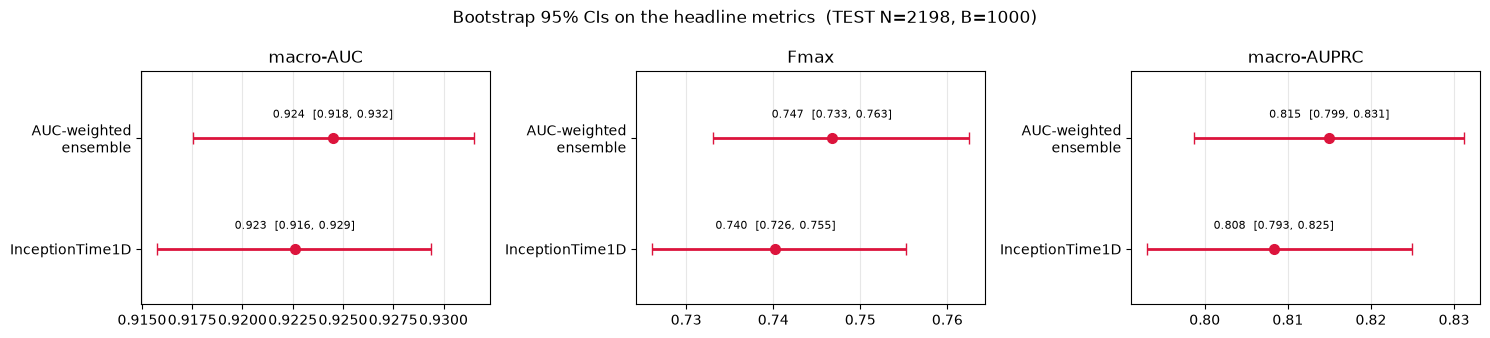

In [8]:
# ---- forest plot: point estimate + 95% CI for every metric / model ----
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, m in zip(axes, metrics):
    rows = [('InceptionTime1D', point_single[m], boot['InceptionTime1D'][m]),
            ('AUC-weighted\nensemble', point_ens[m], boot['AUC-weighted ensemble'][m])]
    for i, (name, pt, v) in enumerate(rows):
        lo, hi = np.percentile(v, CI)
        ax.errorbar(pt, i, xerr=[[pt - lo], [hi - pt]], fmt='o', color='crimson',
                    capsize=4, lw=2, ms=7)
        ax.text(pt, i + 0.18, f'{pt:.3f}  [{lo:.3f}, {hi:.3f}]', ha='center', fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels([r[0] for r in rows]); ax.set_ylim(-0.5, 1.6)
    ax.set_title(m); ax.grid(axis='x', alpha=0.3)
fig.suptitle(f'Bootstrap 95% CIs on the headline metrics  (TEST N={N}, B={N_BOOT})', fontsize=12)
fig.tight_layout(); fig.savefig(OUTPUTS_VAL / '07_bootstrap_headline_ci.png', dpi=200); plt.show()

## Module 6 — Per-class AUC with bootstrap CIs

This is where AUPRC-style sensitivity to the rare classes becomes visible: **HYP** (262 positives)
and **CD** (496) get the widest intervals. Reported for the AUC-weighted ensemble.

class   point AUC              95% CI  CI width
NORM       0.9483   [0.9401, 0.9562]    0.0162
MI         0.9209   [0.9086, 0.9336]    0.0250
STTC       0.9361   [0.9247, 0.9460]    0.0214
CD         0.9148   [0.8996, 0.9287]    0.0291
HYP        0.9023   [0.8812, 0.9232]    0.0420


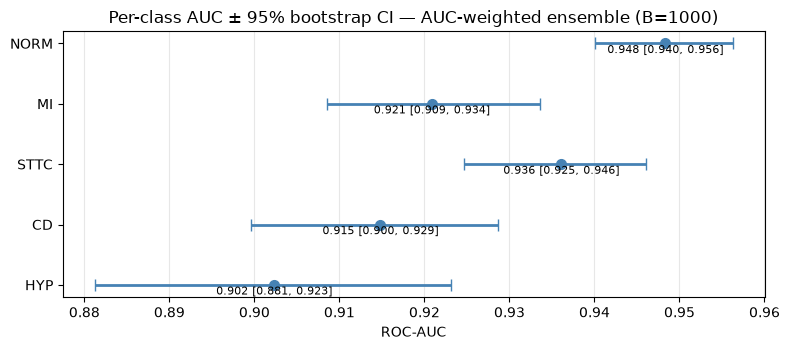

In [9]:
pc = np.empty((N_BOOT, NUM_CLASSES))
for b in range(N_BOOT):
    idx = rng.integers(0, N, size=N)
    for k in range(NUM_CLASSES):
        pc[b, k] = roc_auc_score(y_test[idx, k], P_ens[idx, k])

print(f'{"class":<6s}{"point AUC":>11s}{"95% CI":>20s}{"CI width":>10s}')
for k, sc in enumerate(SUPERCLASSES):
    pt = roc_auc_score(y_test[:, k], P_ens[:, k]); lo, hi = np.percentile(pc[:, k], CI)
    print(f'{sc:<6s}{pt:>11.4f}   [{lo:.4f}, {hi:.4f}]{hi-lo:>10.4f}')

fig, ax = plt.subplots(figsize=(8, 3.6))
for k, sc in enumerate(SUPERCLASSES):
    pt = roc_auc_score(y_test[:, k], P_ens[:, k]); lo, hi = np.percentile(pc[:, k], CI)
    ax.errorbar(pt, k, xerr=[[pt - lo], [hi - pt]], fmt='o', color='steelblue', capsize=4, lw=2, ms=7)
    ax.text(pt, k + 0.16, f'{pt:.3f} [{lo:.3f}, {hi:.3f}]', ha='center', fontsize=8)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(SUPERCLASSES); ax.invert_yaxis()
ax.set_xlabel('ROC-AUC'); ax.grid(axis='x', alpha=0.3)
ax.set_title(f'Per-class AUC ± 95% bootstrap CI — AUC-weighted ensemble (B={N_BOOT})')
fig.tight_layout(); fig.savefig(OUTPUTS_VAL / '07_per_class_auc_ci.png', dpi=200); plt.show()

## Module 7 — Paired test: does the ensemble beat the best single model?

NB02/NB03 observed that the AUC-weighted ensemble does **not** clearly beat `InceptionTime1D` alone.
Using the paired bootstrap draws from Module 5, we form the per-draw difference
`Δ = macro-AUC(ensemble) − macro-AUC(InceptionTime1D)` and report its 95% CI and the fraction of
draws in which the ensemble wins. If the CI contains 0, the "ensemble gain" is **not statistically
distinguishable from noise** on this test set (consistent with Strodthoff 2020's error-bar remark).

macro-AUC      Δ(ens - single) mean +0.0018   95% CI [-0.0010, +0.0045]   ensemble wins 90.1% of draws   -> CI contains 0 -> NOT significant
Fmax           Δ(ens - single) mean +0.0068   95% CI [-0.0017, +0.0147]   ensemble wins 93.3% of draws   -> CI contains 0 -> NOT significant
macro-AUPRC    Δ(ens - single) mean +0.0066   95% CI [+0.0002, +0.0131]   ensemble wins 97.6% of draws   -> CI excludes 0 -> significant


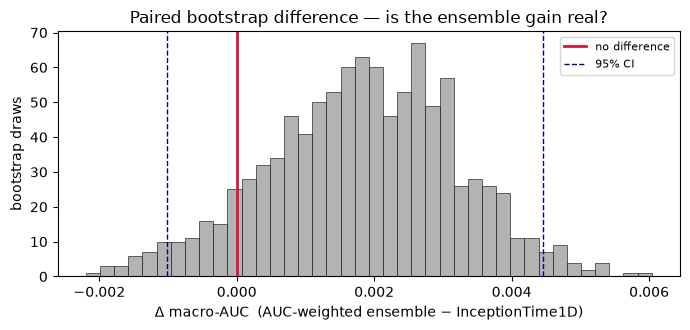

In [10]:
for m in metrics:
    d = boot['AUC-weighted ensemble'][m] - boot['InceptionTime1D'][m]
    lo, hi = np.percentile(d, CI)
    win = float(np.mean(d > 0))
    verdict = 'CI excludes 0 -> significant' if (lo > 0 or hi < 0) else 'CI contains 0 -> NOT significant'
    print(f'{m:<14s} Δ(ens - single) mean {d.mean():+.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]   '
          f'ensemble wins {win*100:4.1f}% of draws   -> {verdict}')

fig, ax = plt.subplots(figsize=(7, 3.4))
d = boot['AUC-weighted ensemble']['macro-AUC'] - boot['InceptionTime1D']['macro-AUC']
ax.hist(d, bins=40, color='0.7', edgecolor='k', lw=0.4)
lo, hi = np.percentile(d, CI)
ax.axvline(0, color='crimson', lw=2, label='no difference')
ax.axvline(lo, color='navy', ls='--', lw=1); ax.axvline(hi, color='navy', ls='--', lw=1, label='95% CI')
ax.set_xlabel('Δ macro-AUC  (AUC-weighted ensemble − InceptionTime1D)')
ax.set_ylabel('bootstrap draws'); ax.legend(fontsize=8)
ax.set_title('Paired bootstrap difference — is the ensemble gain real?')
fig.tight_layout(); fig.savefig(OUTPUTS_VAL / '07_ensemble_vs_single_delta.png', dpi=200); plt.show()

## Module 8 — Headline numbers vs the literature, now with intervals

Only multi-label super-diagnostic macro-AUC rows are directly comparable. Our interval is the
Module 5 bootstrap CI for `InceptionTime1D`.

In [11]:
lo_s, hi_s = np.percentile(boot['InceptionTime1D']['macro-AUC'], CI)
lo_e, hi_e = np.percentile(boot['AUC-weighted ensemble']['macro-AUC'], CI)
rows = [
    ("Strodthoff 2020  xresnet1d101 (single)", "0.920", "bootstrap 1000x (paper)"),
    ("Strodthoff 2020  6-model ensemble",      "0.928", "bootstrap 1000x (paper)"),
    ("Gitau 2025  InceptionTime (repro)",      "0.918", "3x bootstrap (paper)"),
    ("Gitau 2025  ensemble",                   "0.934", "3x bootstrap (paper)"),
    ("This work  InceptionTime1D",   f"{point_single['macro-AUC']:.3f}  [{lo_s:.3f}, {hi_s:.3f}]", f"this notebook, B={N_BOOT}"),
    ("This work  AUC-weighted ens.", f"{point_ens['macro-AUC']:.3f}  [{lo_e:.3f}, {hi_e:.3f}]",    f"this notebook, B={N_BOOT}"),
]
print(f'{"model":<40s}{"macro-AUC (95% CI)":<26s}{"CI source"}')
for r in rows:
    print(f'{r[0]:<40s}{r[1]:<26s}{r[2]}')
print("\nReading: the published SOTA point estimates (0.920-0.934) fall inside — or within a few\n"
      "thousandths of — this work's 95% CI. The gap to SOTA is not statistically resolved on one fold.")

model                                   macro-AUC (95% CI)        CI source
Strodthoff 2020  xresnet1d101 (single)  0.920                     bootstrap 1000x (paper)
Strodthoff 2020  6-model ensemble       0.928                     bootstrap 1000x (paper)
Gitau 2025  InceptionTime (repro)       0.918                     3x bootstrap (paper)
Gitau 2025  ensemble                    0.934                     3x bootstrap (paper)
This work  InceptionTime1D              0.923  [0.916, 0.929]     this notebook, B=1000
This work  AUC-weighted ens.            0.924  [0.918, 0.932]     this notebook, B=1000

Reading: the published SOTA point estimates (0.920-0.934) fall inside — or within a few
thousandths of — this work's 95% CI. The gap to SOTA is not statistically resolved on one fold.


## Module 9 — Conclusion

**What this notebook delivers**

| Output | File | Use |
|---|---|---|
| Bootstrap 95% CIs for macro-AUC, Fmax, macro-AUPRC (both headline models) | `07_bootstrap_headline_ci.png` | every headline number in the paper/deck now carries an interval |
| Per-class AUC ± 95% CI | `07_per_class_auc_ci.png` | shows HYP / CD uncertainty that the point estimate hides |
| Paired ensemble − single Δ with 95% CI | `07_ensemble_vs_single_delta.png` | quantifies the "ensemble adds nothing" claim |
| Literature table with our CI | printed | positions the result against SOTA honestly |

**How every choice is anchored**
- 1000× non-parametric bootstrap, percentile CI: Strodthoff et al. 2020, Appendix I.
- Fmax (threshold swept to maximise F1): Strodthoff et al. 2020, §III.
- macro-AUPRC: Jafari & Jafari 2026 (reported to expose rare-class difficulty).
- Paired resampling for model comparison: standard practice for correlated predictors on one test set.

**Still open (roadmap Tier 2–3, not this notebook)**
- Close the ~0.005 macro-AUC gap to SOTA with Gitau's InceptionTime configuration (depth 12,
  kernels (40, 20, 10), weighted-BCE, ≥ 25 epochs), then re-run NB05–07 on the new checkpoint.
- Improve — not just report — the 80+ subgroup calibration.
- Ablate the HYP Gaussian-noise augmentation (Atwa's own result shows it can hurt).
- Add LRP-ε as a second attribution method and bootstrap the per-lead I_l ranking in NB06.